In [18]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [32]:
FILE_PATH = "defects.csv"

df = pd.read_csv(FILE_PATH)

df['Sample_dt'] = pd.to_datetime(df['Sample'], format='%H:%M')
df['date'] = pd.to_datetime("2024-01-01") + pd.to_timedelta(df["Day"] - 1, unit="D")
df["timestamp"] = df["date"].dt.floor("D") + df["Sample_dt"].dt.time.astype(str).map(
    lambda x: pd.to_timedelta(x)
)
df['hours'] = df['Sample_dt'].dt.hour
df['min'] = df['Sample_dt'].dt.minute
# сортировка по времени
df = df.sort_values(["Day", "Sample_dt"]).reset_index(drop=True)

df["t"] = np.arange(1, len(df) + 1)


df = df[["t", "Day", "Sample", "Sample_dt", "timestamp", "Defects", "hours", "min"]]


df[:20]

,t,Day,Sample,Sample_dt,timestamp,Defects,hours,min
0,1,1,08:15,1900-01-01 08:15:00,2024-01-01 08:15:00,12,8,15
1,2,1,08:30,1900-01-01 08:30:00,2024-01-01 08:30:00,8,8,30
2,3,1,08:45,1900-01-01 08:45:00,2024-01-01 08:45:00,9,8,45
3,4,1,09:00,1900-01-01 09:00:00,2024-01-01 09:00:00,11,9,0
4,5,1,09:15,1900-01-01 09:15:00,2024-01-01 09:15:00,9,9,15
5,6,1,09:30,1900-01-01 09:30:00,2024-01-01 09:30:00,10,9,30
6,7,1,09:45,1900-01-01 09:45:00,2024-01-01 09:45:00,12,9,45
7,8,1,10:00,1900-01-01 10:00:00,2024-01-01 10:00:00,9,10,0
8,9,1,10:15,1900-01-01 10:15:00,2024-01-01 10:15:00,12,10,15
9,10,1,10:30,1900-01-01 10:30:00,2024-01-01 10:30:00,4,10,30


In [29]:
dff = pd.read_csv(FILE_PATH)

dff['Time'] = pd.to_datetime(dff['Sample'], format='%H:%M')

,Day,Sample,Defects
0,1,08:15,12
1,1,08:30,8
2,1,08:45,9
3,1,09:00,11
4,1,09:15,9
5,1,09:30,10
6,1,09:45,12
7,1,10:00,9
8,1,10:15,12
9,1,10:30,4


In [27]:
desc = df["Defects"].describe()
print(desc)

# среднее, std, min, max
mean_val = df["Defects"].mean()
std_val = df["Defects"].std(ddof=1)
min_val = df["Defects"].min()
max_val = df["Defects"].max()

print(f"mean = {mean_val:.3f}")
print(f"std = {std_val:.3f}")
print(f"min = {min_val}")
print(f"max = {max_val}")

count    320.000000
mean      10.325000
std        3.172274
min        1.000000
25%        8.000000
50%       11.000000
75%       12.000000
max       18.000000
Name: Defects, dtype: float64
mean = 10.325
std = 3.172
min = 1
max = 18


# Гистограмма распределения

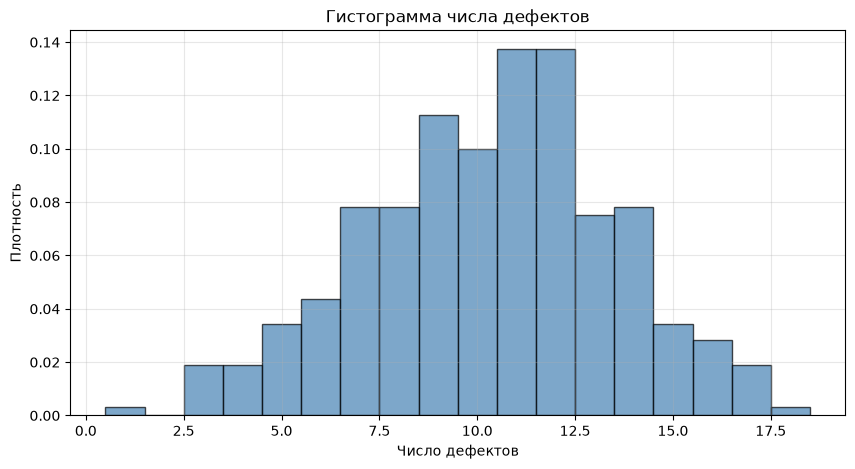

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="steelblue", edgecolor="black")
plt.title("Гистограмма числа дефектов")
plt.xlabel("Число дефектов")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)
plt.show()

# Проверка на Пуассоновское распределение


In [20]:
x = df["Defects"]
mean = x.mean()
var = x.var(ddof=1)

print(f"Среднее: {mean:.4f}")
print(f"Дисперсия: {var:.4f}")
print(f"Отношение var/mean: {var/mean:.4f}")

Среднее: 10.3250
Дисперсия: 10.0633
Отношение var/mean: 0.9747


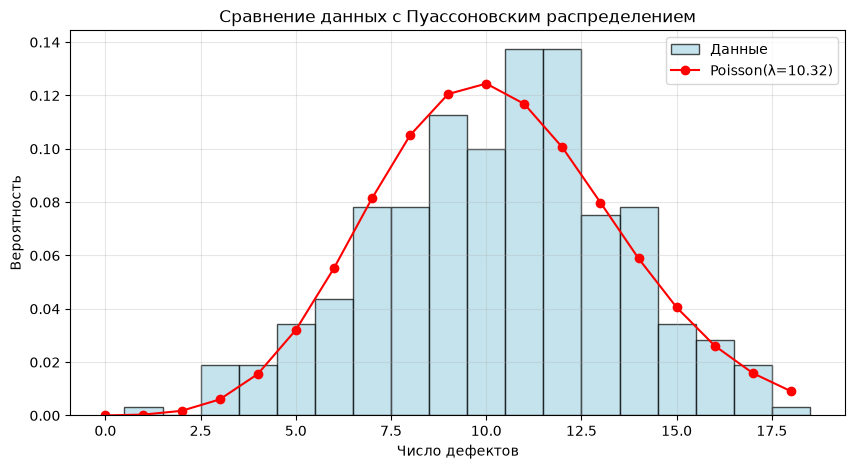

In [21]:
from scipy.stats import poisson

lam = df["Defects"].mean()
k = np.arange(0, df["Defects"].max() + 1)

plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="lightblue", edgecolor="black", label="Данные")
plt.plot(k, poisson.pmf(k, lam), "ro-", label=f"Poisson(λ={lam:.2f})")
plt.title("Сравнение данных с Пуассоновским распределением")
plt.xlabel("Число дефектов")
plt.ylabel("Вероятность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Среднее: 10.325
Стандартное отклонение: 3.172
UCL = 19.842
LCL = 0.808
Точки вне контроля:
Empty DataFrame
Columns: [t, Defects]
Index: []


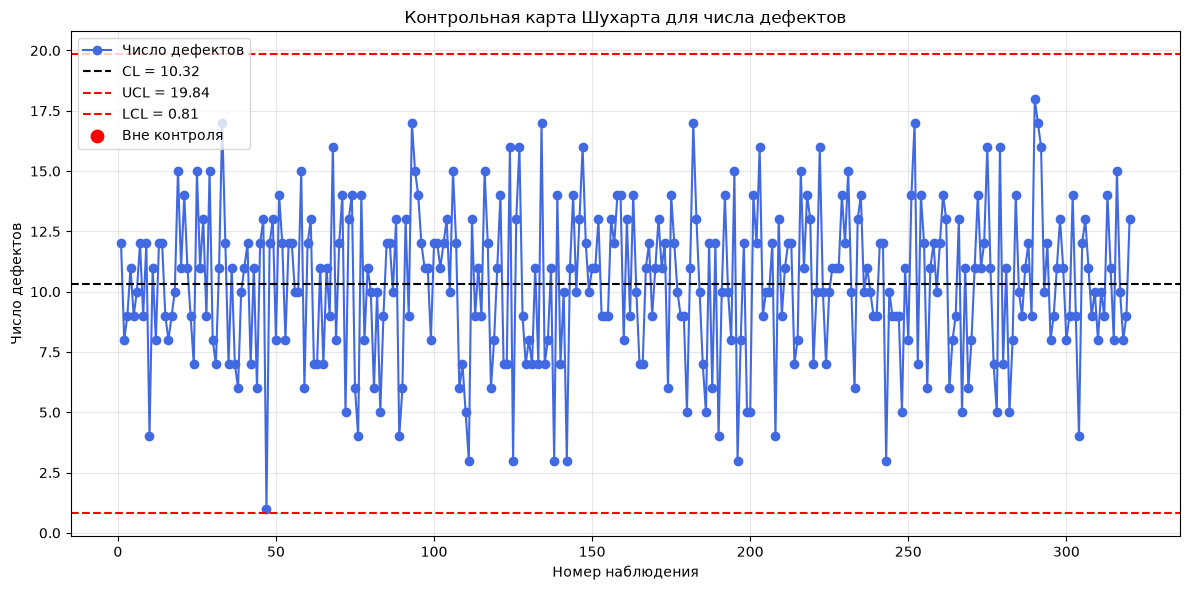

In [30]:
# --- Шухарт для числа дефектов ---
mean_val = df["Defects"].mean()
std_val = df["Defects"].std(ddof=1)

ucl = mean_val + 3 * std_val
lcl = max(mean_val - 3 * std_val, 0)

# флаг точек вне контроля
out_of_control = (df["Defects"] > ucl) | (df["Defects"] < lcl)

df["out_of_control"] = out_of_control

print(f"Среднее: {mean_val:.3f}")
print(f"Стандартное отклонение: {std_val:.3f}")
print(f"UCL = {ucl:.3f}")
print(f"LCL = {lcl:.3f}")
print("Точки вне контроля:")
print(df.loc[out_of_control, ["t", "Defects"]])

plt.figure(figsize=(12, 6))
plt.plot(df["t"], df["Defects"], marker="o", color="royalblue", linewidth=1.5, label="Число дефектов")
plt.axhline(mean_val, color="black", linestyle="--", linewidth=1.5, label=f"CL = {mean_val:.2f}")
plt.axhline(ucl, color="red", linestyle="--", linewidth=1.5, label=f"UCL = {ucl:.2f}")
plt.axhline(lcl, color="red", linestyle="--", linewidth=1.5, label=f"LCL = {lcl:.2f}")
plt.scatter(df.loc[out_of_control, "t"], df.loc[out_of_control, "Defects"], color="red", s=80, zorder=5, label="Вне контроля")
plt.title("Контрольная карта Шухарта для числа дефектов")
plt.xlabel("Номер наблюдения")
plt.ylabel("Число дефектов")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Шухарт по времени суток (часы + минуты) ---
df["hour"] = df["Sample_dt"].dt.hour
df["minute"] = df["Sample_dt"].dt.minute
df["minute_of_day"] = df["hour"] * 60 + df["minute"]

mean_time = df["Defects"].mean()
std_time = df["Defects"].std(ddof=1)

ucl_time = mean_time + 3 * std_time
lcl_time = max(mean_time - 3 * std_time, 0)

df["out_of_control_time"] = (df["Defects"] > ucl_time) | (df["Defects"] < lcl_time)

print(f"Среднее: {mean_time:.3f}")
print(f"Стандартное отклонение: {std_time:.3f}")
print(f"UCL = {ucl_time:.3f}")
print(f"LCL = {lcl_time:.3f}")
print("Точки вне контроля по времени:")
print(df.loc[df["out_of_control_time"], ["timestamp", "hour", "minute", "Defects"]])

plt.figure(figsize=(14, 6))
plt.plot(df["minute_of_day"], df["Defects"], marker="o", color="royalblue", linewidth=1.5, label="Число дефектов")
plt.axhline(mean_time, color="black", linestyle="--", linewidth=1.5, label=f"CL = {mean_time:.2f}")
plt.axhline(ucl_time, color="red", linestyle="--", linewidth=1.5, label=f"UCL = {ucl_time:.2f}")
plt.axhline(lcl_time, color="red", linestyle="--", linewidth=1.5, label=f"LCL = {lcl_time:.2f}")
plt.scatter(
    df.loc[df["out_of_control_time"], "minute_of_day"],
    df.loc[df["out_of_control_time"], "Defects"],
    color="red", s=80, zorder=5, label="Вне контроля"
)
plt.title("Контрольная карта Шухарта по времени суток")
plt.xlabel("Время суток (минуты с начала дня)")
plt.ylabel("Число дефектов")
plt.xticks(np.arange(0, 1440, 120), [f"{h:02d}:00" for h in range(0, 24, 2)])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()